# Triangle Field Voxel Visualization

Load one processed triangle-field voxelization (`.npz` or `.npz.zst`) and visualize the stored channels. The rasterized views use TRELLIS/o_voxel's `VoxelRenderer`; the Plotly cell is a fallback/interactive sparse point view.

In [1]:
from pathlib import Path

# Dataset / sample selection.
ROOT = Path('/nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k')
GAUSSIAN_DISTANCE_ROOT = ROOT
RESOLUTION = 256

# Choose exactly one of these. If both are None, a random processed sample is used.
SHA256 = "01e91bfd3ef7d55f8d1adb254d30537803855222e0b6a7f2cb9c68afef6d02d8"
INDEX = None
RANDOM_SEED = 0

# Rendering controls.
RENDER_RESOLUTION = 512
SSAA = 16
POINT_SUBSAMPLE = 200_000
DEVICE = 'cuda'  # VoxelRenderer expects CUDA in normal TRELLIS usage.

In [2]:
import io
import json
import random
import sys

import numpy as np
import torch
from IPython.display import display
from PIL import Image

REPO = Path('/home/gpranav/pranav_work/scratch/TRELLIS.2')
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from trellis2.renderers import VoxelRenderer
from trellis2.representations import Voxel
import utils3d
import o_voxel

INPUT_LAYOUT = [
    ('d_tri', slice(0, 1)),
    ('d_vert', slice(1, 2)),
    ('offset_to_v0', slice(2, 5)),
    ('offset_to_v1', slice(5, 8)),
    ('offset_to_v2', slice(8, 11)),
    ('offset_to_centroid', slice(11, 14)),
    ('face_normal', slice(14, 17)),
    ('offset_to_projection', slice(17, 20)),
]
TARGET_LAYOUT = [('d_tri', slice(0, 1)), ('d_vert', slice(1, 2))]

def load_npz_or_zstd(path):
    path = Path(path)
    if path.suffix == '.zst':
        import zstandard as zstd
        payload = zstd.ZstdDecompressor().decompress(path.read_bytes())
        return np.load(io.BytesIO(payload), allow_pickle=False)
    return np.load(path, allow_pickle=False)

def list_processed(root, resolution):
    stage = Path(root) / f'triangle_field_voxels_{resolution}'
    files = sorted(stage.glob('*.npz.zst')) + sorted(stage.glob('*.npz'))
    files = [p for p in files if '.tmp' not in p.name]
    if not files:
        raise FileNotFoundError(f'No triangle-field voxel files found in {stage}')
    return files

def choose_sample(root, resolution, sha256=None, index=None, seed=0):
    files = list_processed(root, resolution)
    by_sha = {p.name.split('.npz')[0]: p for p in files}
    if sha256 is not None:
        if sha256 not in by_sha:
            raise FileNotFoundError(f'{sha256} was not found under triangle_field_voxels_{resolution}')
        return by_sha[sha256]
    if index is None:
        rng = random.Random(seed)
        return rng.choice(files)
    return files[index]

sample_path = choose_sample(ROOT, RESOLUTION, SHA256, INDEX, RANDOM_SEED)
with load_npz_or_zstd(sample_path) as data:
    coords = data['coords'].astype(np.int32)
    features = data['features'].astype(np.float32)
    inputs = features
    targets = features[:, :2]
    metadata = json.loads(str(data['metadata_json']))

sha = sample_path.name.split('.npz')[0]
points = (coords.astype(np.float32) + 0.5) / float(RESOLUTION) - 0.5
print('sample:', sha)
print('path:', sample_path)
print('coords:', coords.shape, coords.dtype)
print('features:', features.shape, features.dtype)
print('derived targets:', targets.shape, targets.dtype)
print('metadata:', metadata)

sample: 01e91bfd3ef7d55f8d1adb254d30537803855222e0b6a7f2cb9c68afef6d02d8
path: /nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k/triangle_field_voxels_256/01e91bfd3ef7d55f8d1adb254d30537803855222e0b6a7f2cb9c68afef6d02d8.npz.zst
coords: (175353, 3) int32
features: (175353, 20) float32
derived targets: (175353, 2) float32
metadata: {'format': 'triangle_field_voxel_npz', 'version': 2, 'resolution': 256, 'feature_dtype': 'float16', 'npz_compression': 'zstd', 'coordinate_frame': 'normalized_object_space', 'normalization': 'same_as_voxelize_gaussian_distance.normalize_dump', 'feature_layout': [['d_tri', 1], ['d_vert', 1], ['offset_to_v0', 3], ['offset_to_v1', 3], ['offset_to_v2', 3], ['offset_to_centroid', 3], ['face_normal', 3], ['offset_to_projection', 3]], 'definitions': {'voxel_center': '(coords + 0.5) / resolution - 0.5', 'projected_point': 'closest point on nearest triangle', 'd_tri': '3 * min(barycentric(projected_point))', 'd_vert': '(max(barycentric(projected_point)) - 1/3) / (2/3)'}}

In [3]:
# Basic per-channel statistics.
for name, sl in INPUT_LAYOUT:
    x = inputs[:, sl]
    print(f'input {name:>20s}: shape={x.shape}, min={np.nanmin(x): .5f}, mean={np.nanmean(x): .5f}, max={np.nanmax(x): .5f}')
for name, sl in TARGET_LAYOUT:
    x = targets[:, sl]
    print(f'target {name:>19s}: shape={x.shape}, min={np.nanmin(x): .5f}, mean={np.nanmean(x): .5f}, max={np.nanmax(x): .5f}')

input                d_tri: shape=(175353, 1), min= 0.00000, mean= 0.33300, max= 0.99951
input               d_vert: shape=(175353, 1), min= 0.00036, mean= 0.41616, max= 1.00000
input         offset_to_v0: shape=(175353, 3), min=-0.10120, mean=-0.00005, max= 0.09448
input         offset_to_v1: shape=(175353, 3), min=-0.07263, mean= 0.00011, max= 0.07843
input         offset_to_v2: shape=(175353, 3), min=-0.10217, mean=-0.00004, max= 0.10394
input   offset_to_centroid: shape=(175353, 3), min=-0.05179, mean= 0.00001, max= 0.06024
input          face_normal: shape=(175353, 3), min=-1.00000, mean= 0.00179, max= 0.99902
input offset_to_projection: shape=(175353, 3), min=-0.00266, mean= 0.00000, max= 0.00266
target               d_tri: shape=(175353, 1), min= 0.00000, mean= 0.33300, max= 0.99951
target              d_vert: shape=(175353, 1), min= 0.00036, mean= 0.41616, max= 1.00000


In [4]:
import matplotlib.cm as cm

def make_cameras(render_device):
    yaws = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
    pitch = [0.25, 0.25, 0.25, 0.25]
    exts, ints = [], []
    for yaw, pitch_i in zip(yaws, pitch):
        orig = torch.tensor([
            np.sin(yaw) * np.cos(pitch_i),
            np.cos(yaw) * np.cos(pitch_i),
            np.sin(pitch_i),
        ], dtype=torch.float32, device=render_device) * 2.0
        fov = torch.deg2rad(torch.tensor(30.0, device=render_device))
        ext = utils3d.torch.extrinsics_look_at(
            orig,
            torch.tensor([0, 0, 0], dtype=torch.float32, device=render_device),
            torch.tensor([0, 0, 1], dtype=torch.float32, device=render_device),
        )
        intr = utils3d.torch.intrinsics_from_fov_xy(fov, fov)
        exts.append(ext)
        ints.append(intr)
    return exts, ints

def to_image(tensor_chw):
    arr = tensor_chw.detach().clamp(0, 1).cpu().permute(1, 2, 0).numpy()
    return Image.fromarray((arr * 255).astype(np.uint8))

def colormap_values(values, vmin=None, vmax=None, cmap='viridis'):
    values = np.asarray(values, dtype=np.float32).reshape(-1)
    if vmin is None:
        vmin = float(np.nanpercentile(values, 1))
    if vmax is None:
        vmax = float(np.nanpercentile(values, 99))
    denom = max(vmax - vmin, 1e-8)
    t = np.clip((values - vmin) / denom, 0, 1)
    rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)
    return rgb, (vmin, vmax)

def vector_to_rgb(vec, scale=None):
    vec = np.asarray(vec, dtype=np.float32)
    if scale is None:
        scale = float(np.nanpercentile(np.abs(vec), 99))
        scale = max(scale, 1e-8)
    rgb = np.clip(vec / (2 * scale) + 0.5, 0, 1)
    return rgb.astype(np.float32), scale

def render_colors(colors_np, title=''):
    render_device = torch.device(DEVICE)
    renderer = VoxelRenderer({'resolution': RENDER_RESOLUTION, 'ssaa': SSAA})
    rep = Voxel(
        origin=[-0.5, -0.5, -0.5],
        voxel_size=1.0 / RESOLUTION,
        coords=torch.from_numpy(coords).int().to(render_device),
        attrs=None,
        layout={'color': slice(0, 3)},
        device=render_device,
    )
    colors = torch.from_numpy(colors_np.astype(np.float32)).to(render_device)
    exts, ints = make_cameras(render_device)
    image = torch.zeros(3, RENDER_RESOLUTION * 2, RENDER_RESOLUTION * 2, device=render_device)
    for j, (ext, intr) in enumerate(zip(exts, ints)):
        res = renderer.render(rep, ext, intr, colors_overwrite=colors)
        r0 = RENDER_RESOLUTION * (j // 2)
        c0 = RENDER_RESOLUTION * (j % 2)
        image[:, r0:r0 + RENDER_RESOLUTION, c0:c0 + RENDER_RESOLUTION] = res['color']
    if title:
        print(title)
    display(to_image(image))

def render_scalar(values, title='', vmin=None, vmax=None, cmap='viridis'):
    colors, vrange = colormap_values(values, vmin=vmin, vmax=vmax, cmap=cmap)
    render_colors(colors, title=f'{title}  range={vrange}')

def render_vector(vec, title='', scale=None):
    colors, used_scale = vector_to_rgb(vec, scale=scale)
    render_colors(colors, title=f'{title}  RGB maps [-{used_scale:.5g}, +{used_scale:.5g}] to [0, 1]')

## Target scalar fields

/tmp/ipykernel_2670879/4122514555.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)


target d_tri  range=(0, 1)


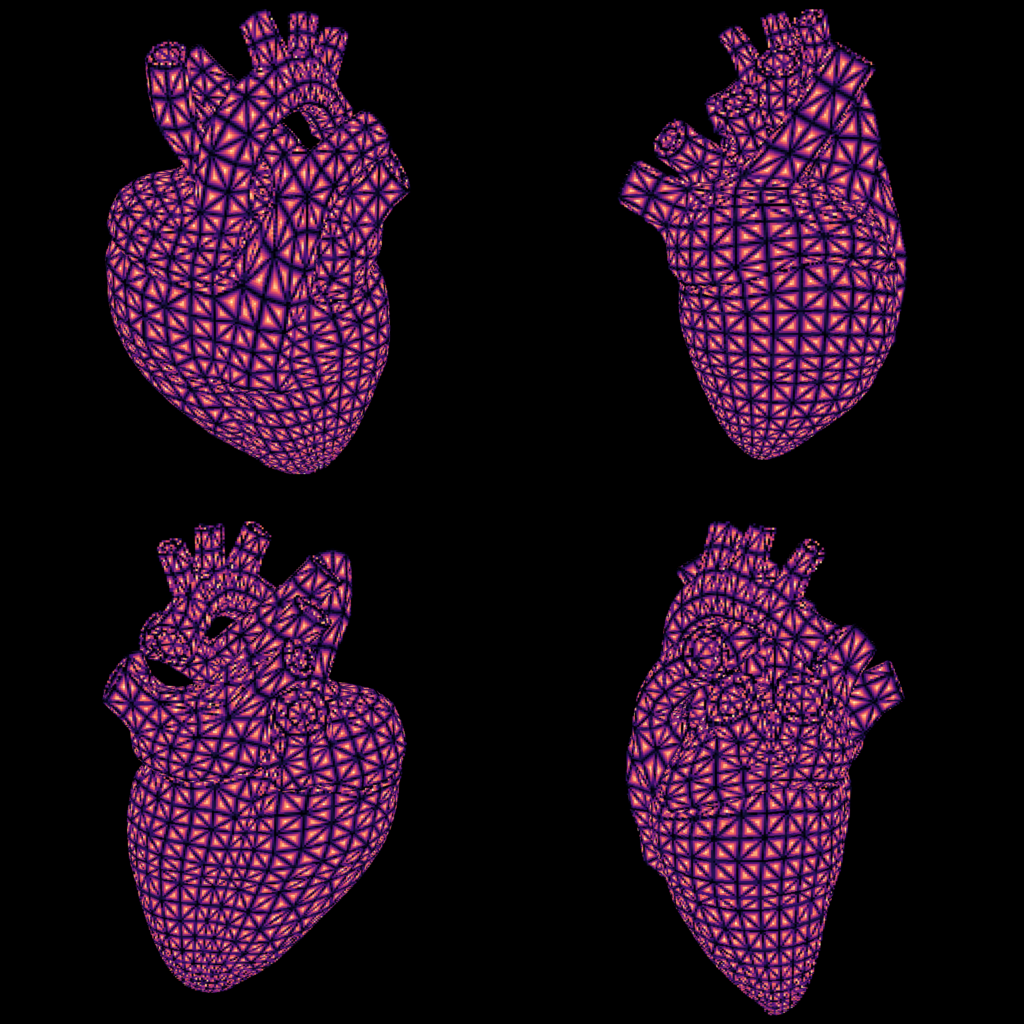

target d_vert  range=(0, 1)


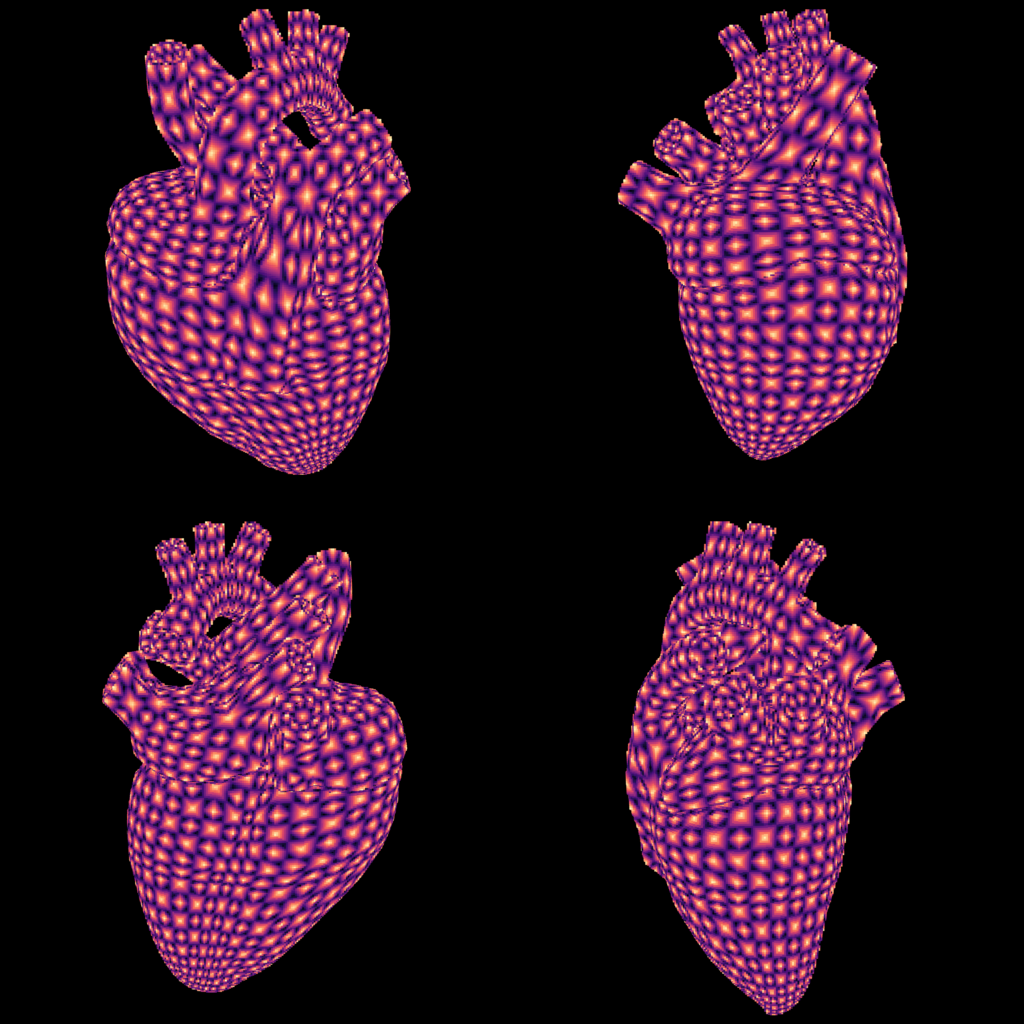

In [5]:
render_scalar(targets[:, 0], title='target d_tri', vmin=0, vmax=1, cmap='magma')
render_scalar(targets[:, 1], title='target d_vert', vmin=0, vmax=1, cmap='magma')

## Comparison to previous Gaussian distance voxels

In [6]:
def load_gaussian_distance_voxels(root, resolution, sha256):
    path = Path(root) / f'gaussian_distance_voxels_{resolution}' / f'{sha256}.vxz'
    if not path.exists():
        raise FileNotFoundError(f'Gaussian-distance vxz not found: {path}')
    g_coords, g_attr = o_voxel.io.read_vxz(str(path), num_threads=4)
    edge_rgb = g_attr['base_color'].float().cpu().numpy()
    vertex_rgb = g_attr['emissive'].float().cpu().numpy()
    if edge_rgb.max(initial=0) > 1.0:
        edge_rgb = edge_rgb / 255.0
    if vertex_rgb.max(initial=0) > 1.0:
        vertex_rgb = vertex_rgb / 255.0
    return g_coords.cpu().numpy().astype(np.int32), edge_rgb.astype(np.float32), vertex_rgb.astype(np.float32), path

def render_voxel_colors(coords_np, colors_np):
    render_device = torch.device(DEVICE)
    renderer = VoxelRenderer({'resolution': RENDER_RESOLUTION, 'ssaa': SSAA})
    rep = Voxel(
        origin=[-0.5, -0.5, -0.5],
        voxel_size=1.0 / RESOLUTION,
        coords=torch.from_numpy(coords_np).int().to(render_device),
        attrs=None,
        layout={'color': slice(0, 3)},
        device=render_device,
    )
    colors = torch.from_numpy(np.clip(colors_np.astype(np.float32), 0, 1)).to(render_device)
    exts, ints = make_cameras(render_device)
    image = torch.zeros(3, RENDER_RESOLUTION * 2, RENDER_RESOLUTION * 2, device=render_device)
    for j, (ext, intr) in enumerate(zip(exts, ints)):
        res = renderer.render(rep, ext, intr, colors_overwrite=colors)
        r0 = RENDER_RESOLUTION * (j // 2)
        c0 = RENDER_RESOLUTION * (j % 2)
        image[:, r0:r0 + RENDER_RESOLUTION, c0:c0 + RENDER_RESOLUTION] = res['color']
    return image

def display_side_by_side(left_chw, right_chw, left_title, right_title):
    left = left_chw.detach().clamp(0, 1).cpu()
    right = right_chw.detach().clamp(0, 1).cpu()
    combined = torch.cat([left, right], dim=2)
    print(f'left: {left_title}')
    print(f'right: {right_title}')
    display(to_image(combined))

g_coords, gaussian_edge_rgb, gaussian_vertex_rgb, gaussian_path = load_gaussian_distance_voxels(
    GAUSSIAN_DISTANCE_ROOT,
    RESOLUTION,
    sha,
)
print('loaded gaussian-distance vxz:', gaussian_path)
print('triangle-field voxels:', len(coords), 'gaussian-distance voxels:', len(g_coords))

loaded gaussian-distance vxz: /nfs/turbo/coe-jjparkcv-medium/gpranav/objxl_4k/gaussian_distance_voxels_256/01e91bfd3ef7d55f8d1adb254d30537803855222e0b6a7f2cb9c68afef6d02d8.vxz
triangle-field voxels: 175353 gaussian-distance voxels: 175353


left: triangle-field target d_tri grayscale
right: gaussian edge-distance RGB


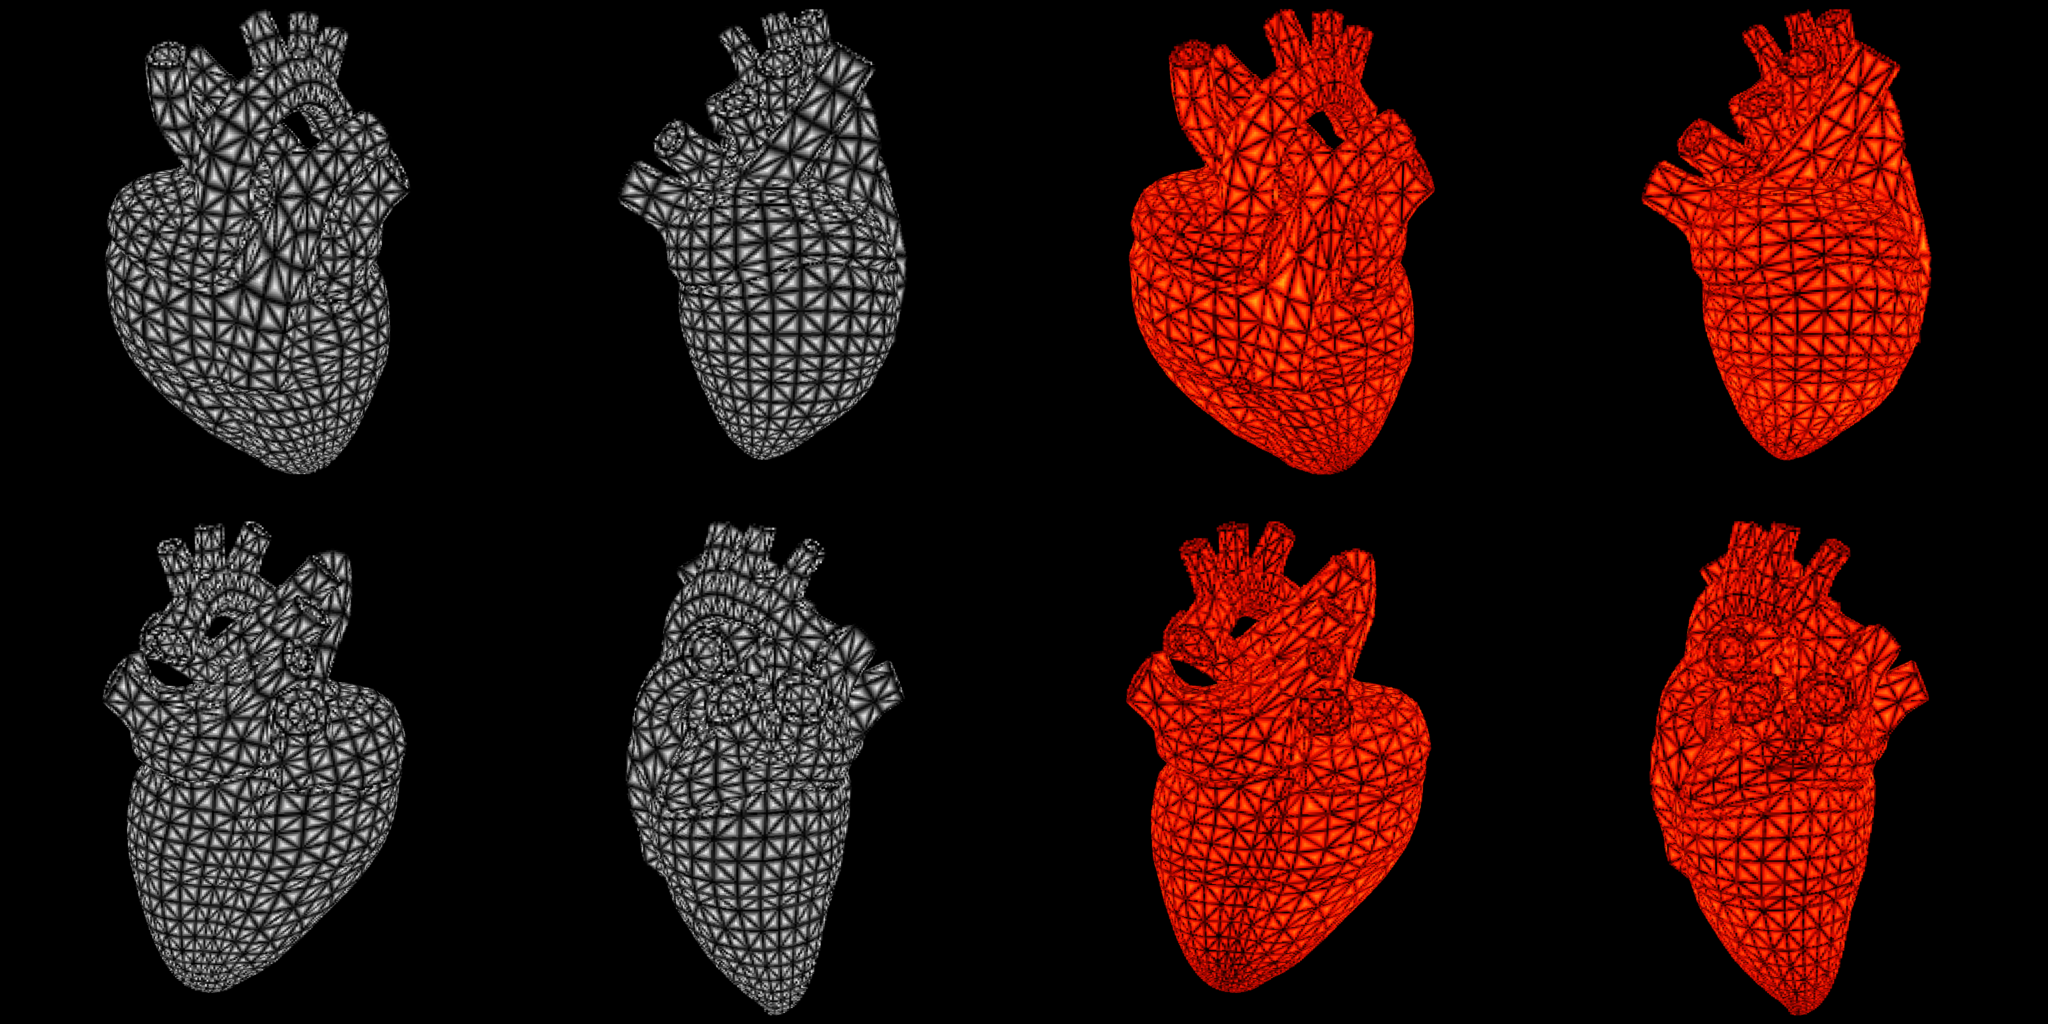

In [7]:
# Side-by-side: triangle d_tri scalar vs previous edge-distance RGB visualization.
tri_d_tri_gray = np.repeat(np.clip(targets[:, 0:1], 0, 1), 3, axis=1)
tri_d_tri_image = render_voxel_colors(coords, tri_d_tri_gray)
edge_distance_image = render_voxel_colors(g_coords, gaussian_edge_rgb)
display_side_by_side(tri_d_tri_image, edge_distance_image, 'triangle-field target d_tri grayscale', 'gaussian edge-distance RGB')

left: triangle-field target d_vert grayscale
right: gaussian vertex-distance RGB


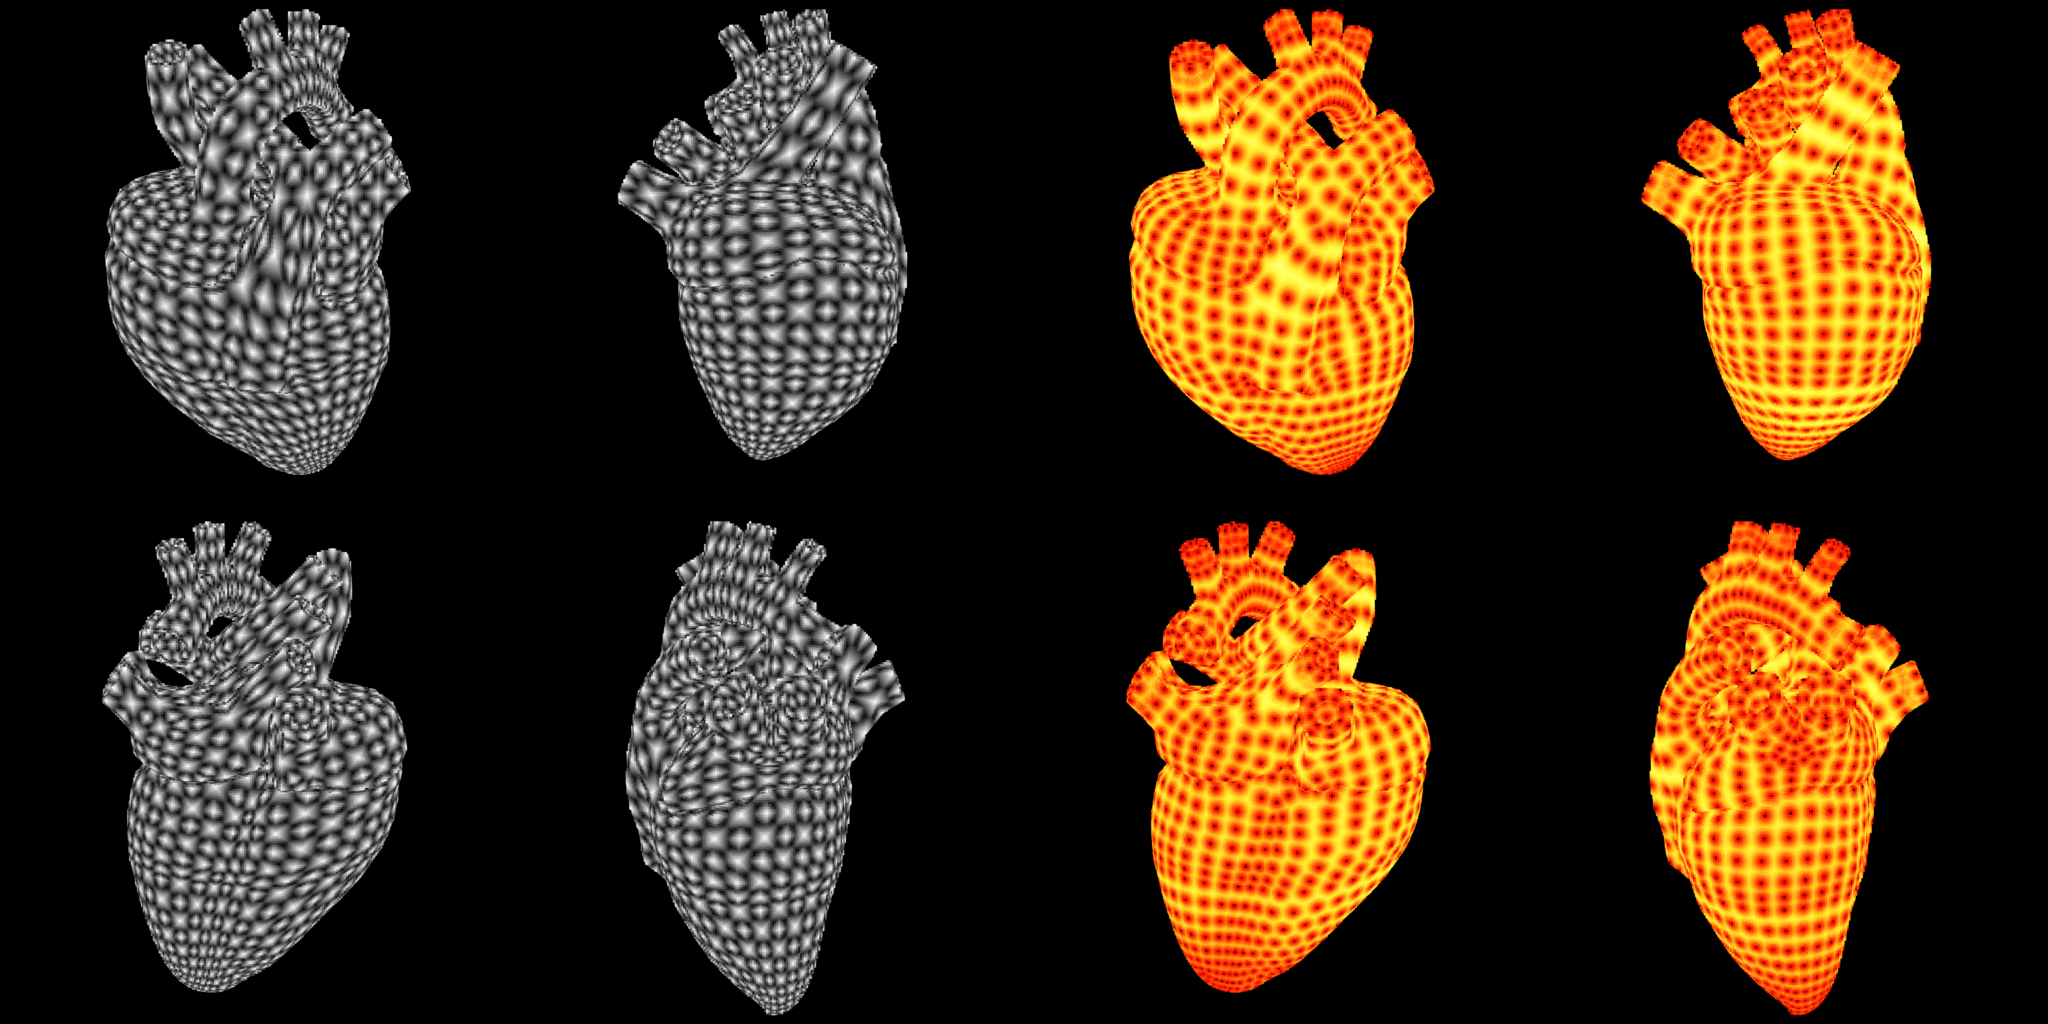

In [8]:
# Side-by-side: triangle d_vert scalar vs previous vertex-distance RGB visualization.
tri_d_vert_gray = np.repeat(np.clip(targets[:, 1:2], 0, 1), 3, axis=1)
tri_d_vert_image = render_voxel_colors(coords, tri_d_vert_gray)
vertex_distance_image = render_voxel_colors(g_coords, gaussian_vertex_rgb)
display_side_by_side(tri_d_vert_image, vertex_distance_image, 'triangle-field target d_vert grayscale', 'gaussian vertex-distance RGB')

## Input scalar fields

input d_tri  range=(0, 1)


/tmp/ipykernel_1873662/4122514555.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)


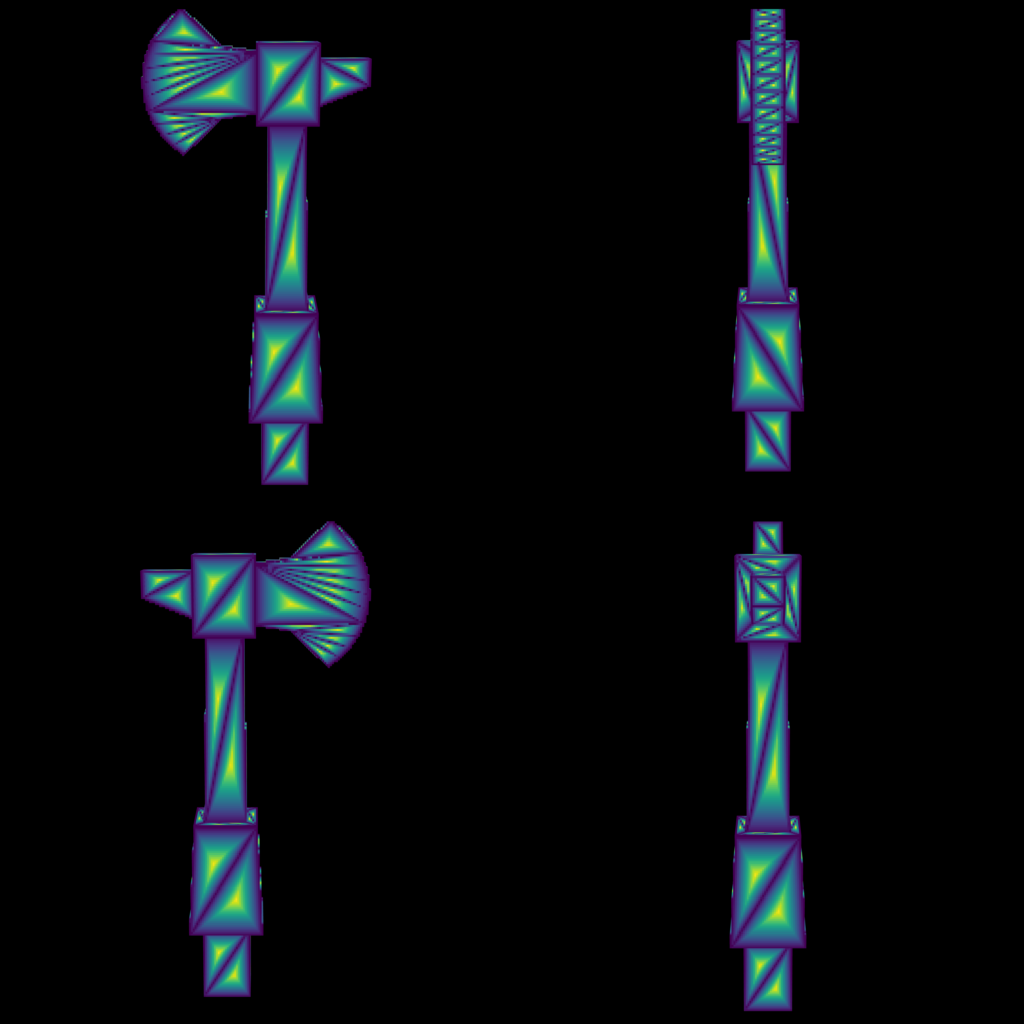

input d_vert  range=(0, 1)


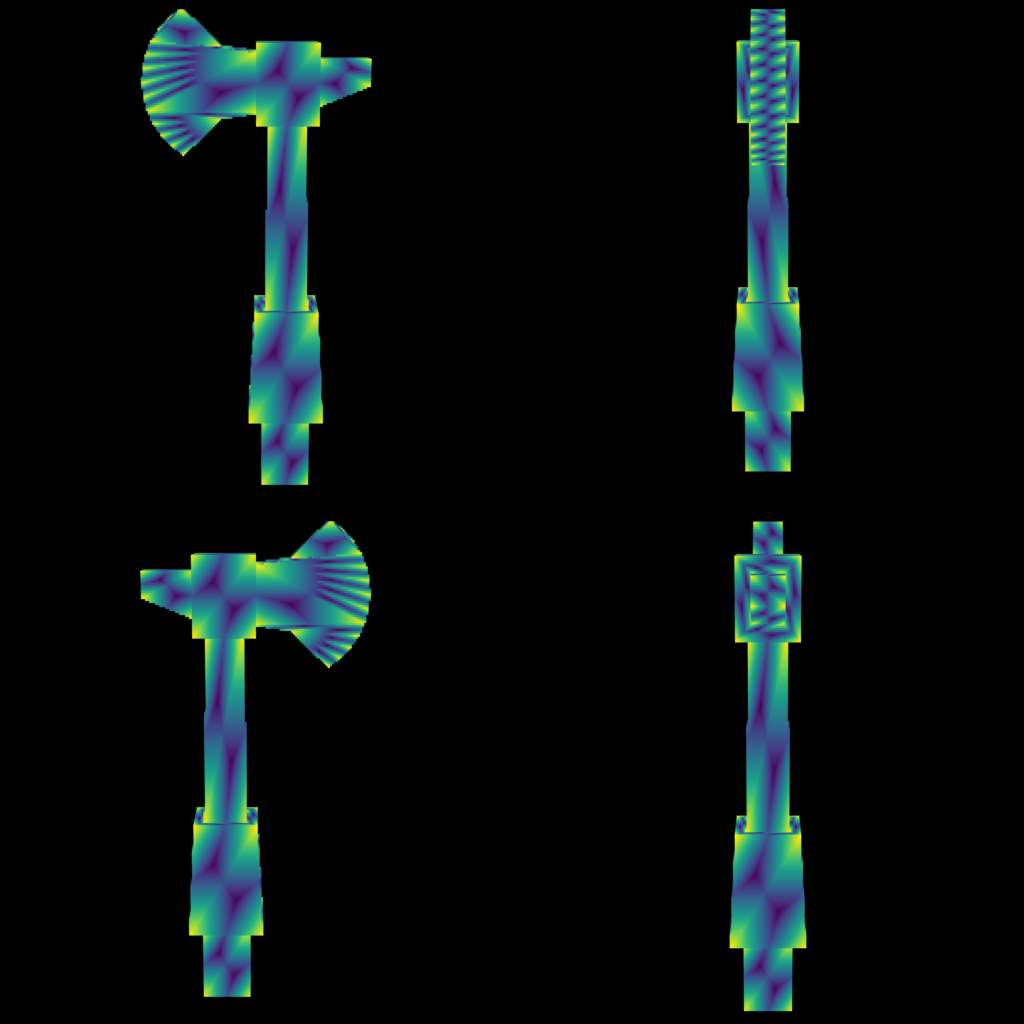

abs(input d_tri - target d_tri)  range=(0, 0.05)


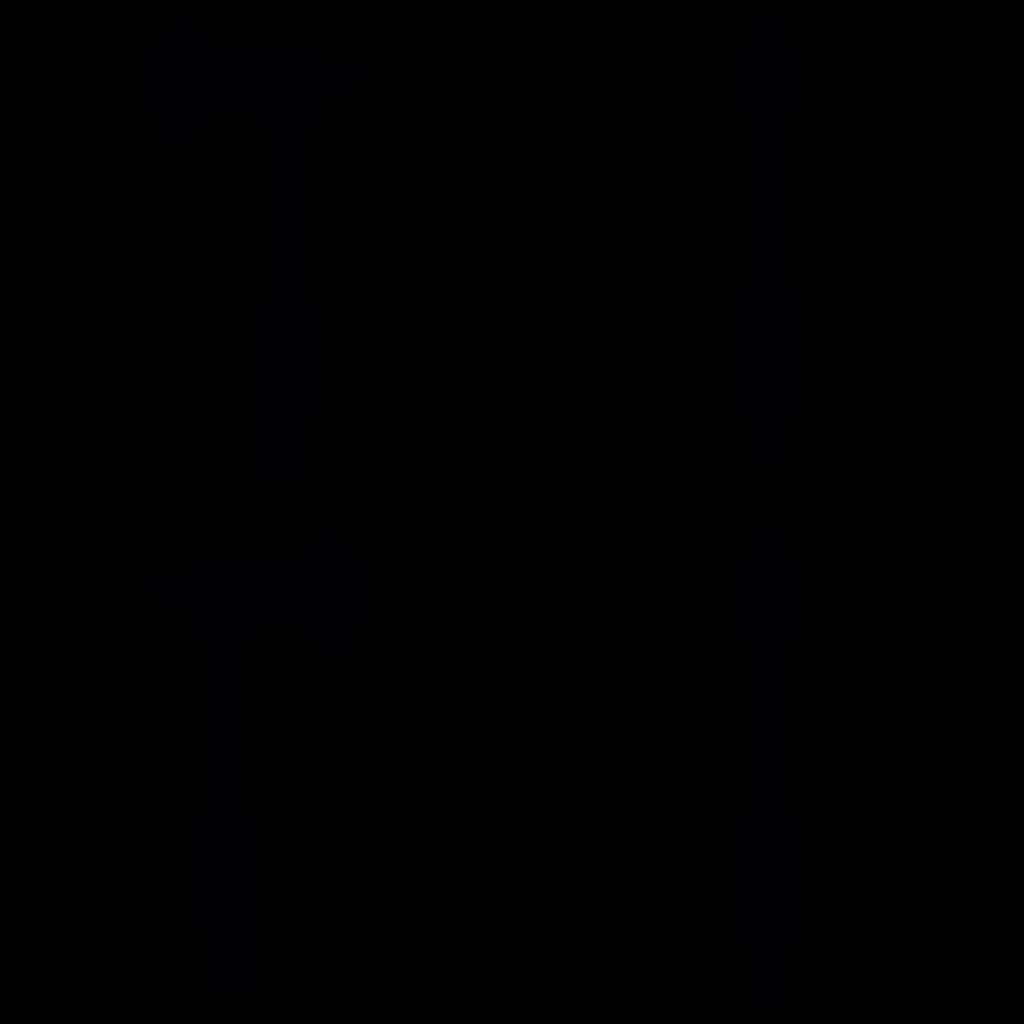

abs(input d_vert - target d_vert)  range=(0, 0.05)


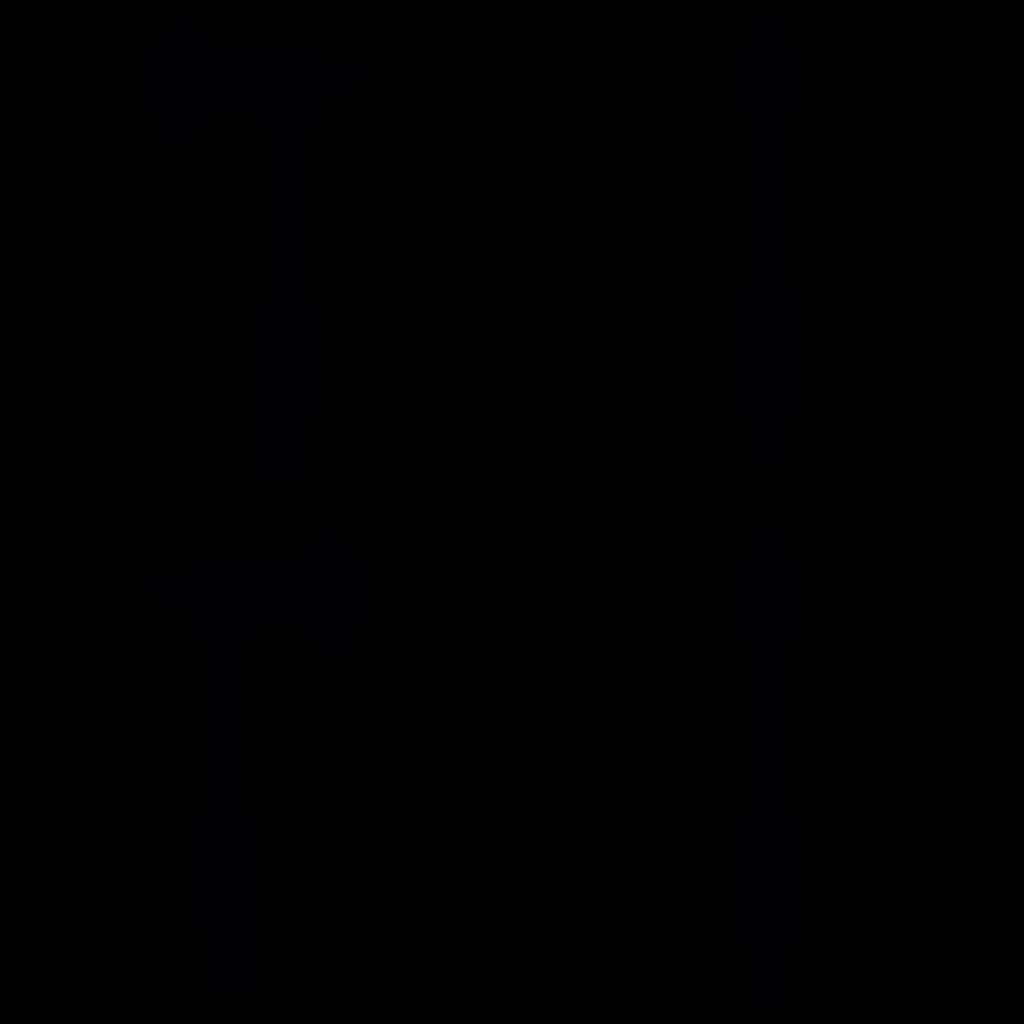

In [9]:
render_scalar(inputs[:, 0], title='input d_tri', vmin=0, vmax=1, cmap='viridis')
render_scalar(inputs[:, 1], title='input d_vert', vmin=0, vmax=1, cmap='viridis')
render_scalar(np.abs(inputs[:, 0] - targets[:, 0]), title='abs(input d_tri - target d_tri)', vmin=0, vmax=0.05, cmap='inferno')
render_scalar(np.abs(inputs[:, 1] - targets[:, 1]), title='abs(input d_vert - target d_vert)', vmin=0, vmax=0.05, cmap='inferno')

## Face normals

face_normal as RGB: normal * 0.5 + 0.5


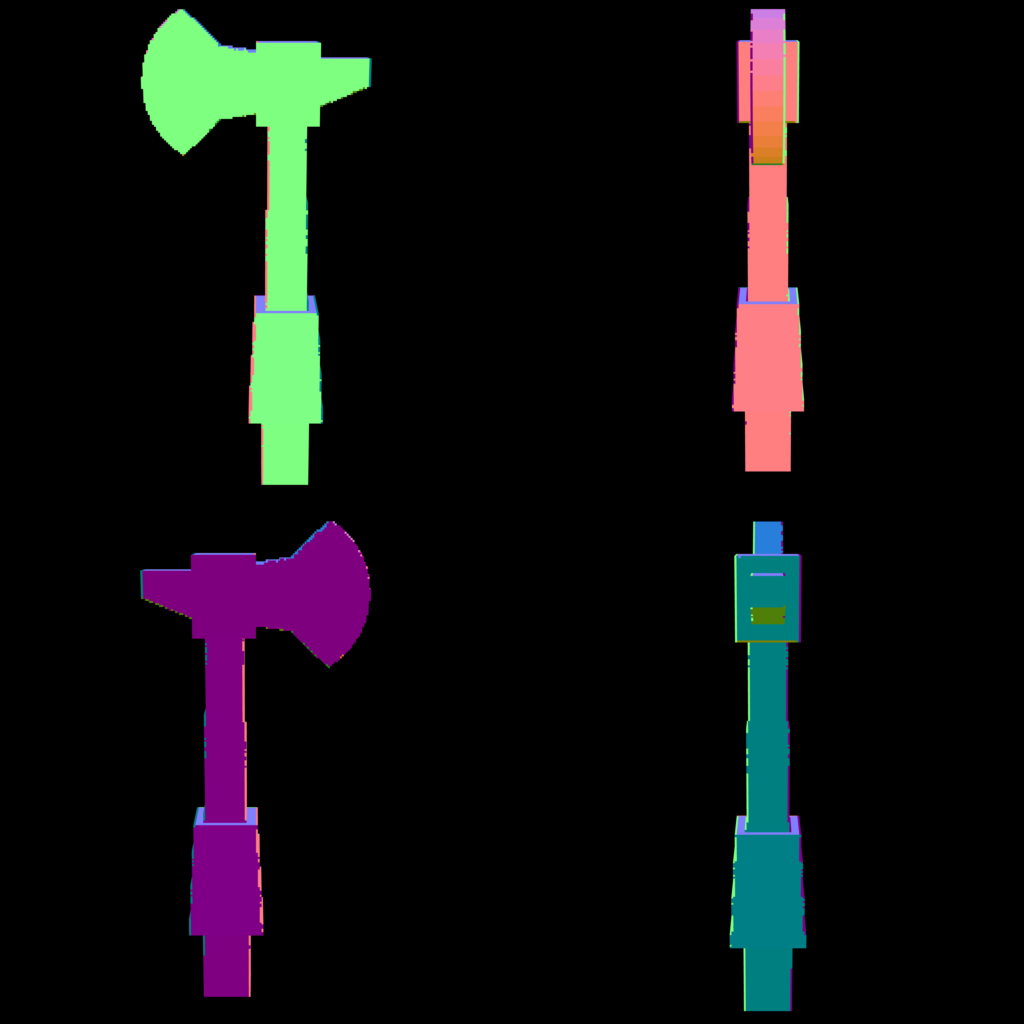

face_normal norm  range=(0.9, 1.1)


/tmp/ipykernel_1873662/4122514555.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)


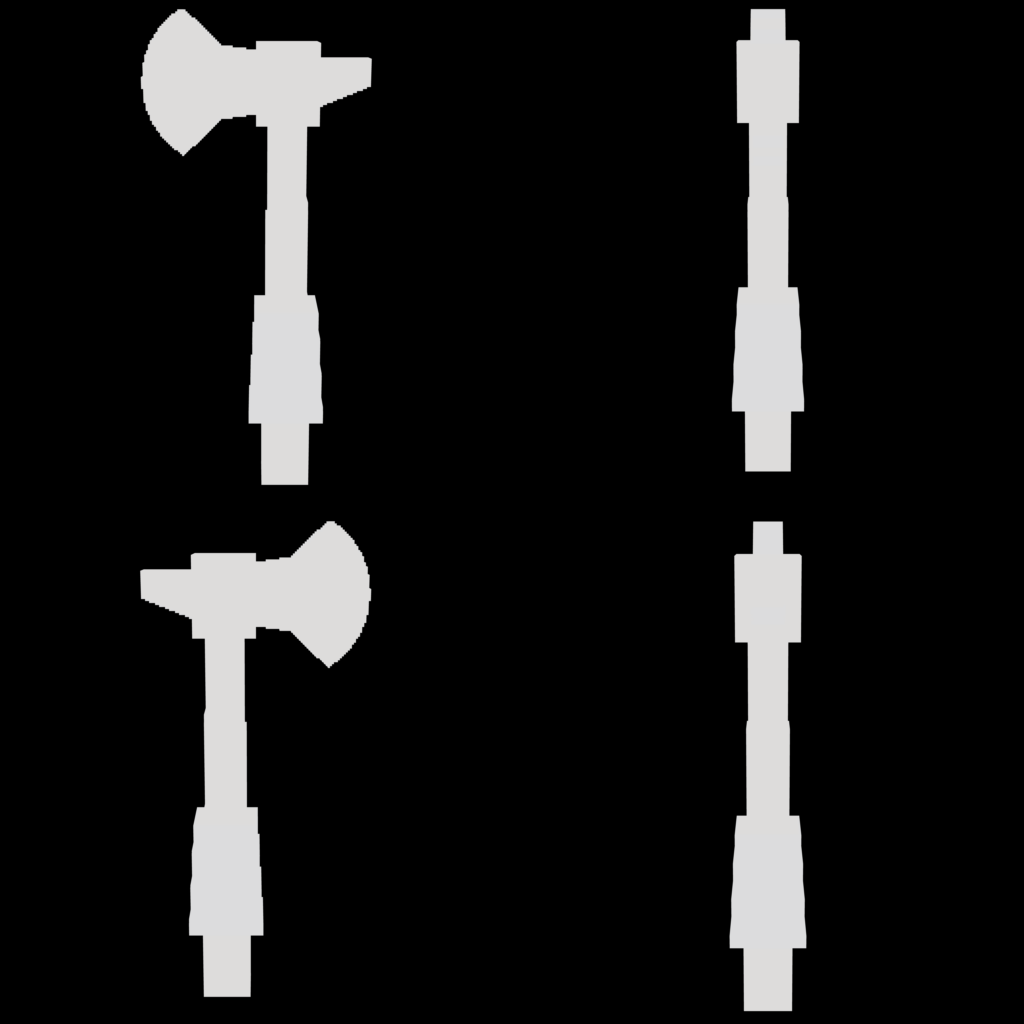

In [10]:
face_normal = inputs[:, 14:17]
render_colors(np.clip(face_normal * 0.5 + 0.5, 0, 1), title='face_normal as RGB: normal * 0.5 + 0.5')
render_scalar(np.linalg.norm(face_normal, axis=1), title='face_normal norm', vmin=0.9, vmax=1.1, cmap='coolwarm')

## Offset to projection

offset_to_projection vector  RGB maps [-0.0019522, +0.0019522] to [0, 1]


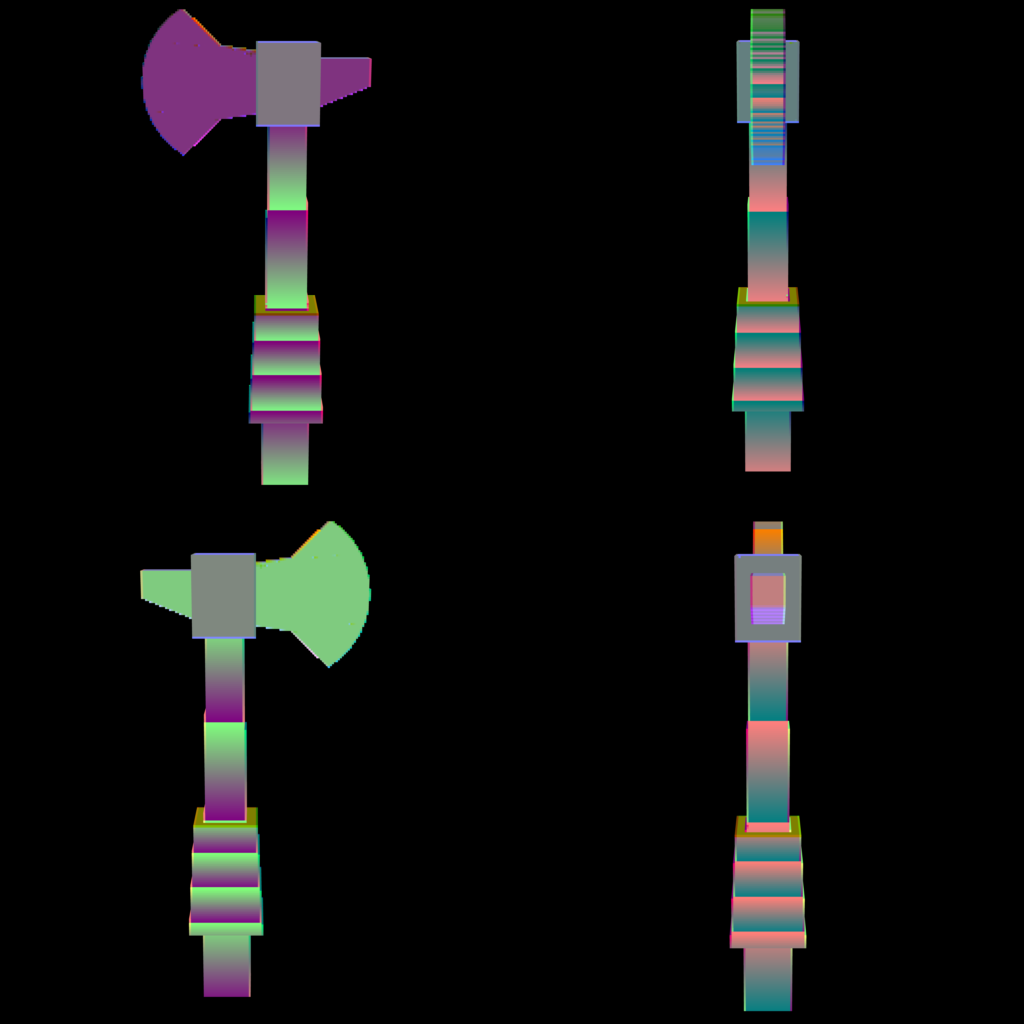

|offset_to_projection|  range=(3.0642586352769285e-05, 0.0023171911016106606)


/tmp/ipykernel_1873662/4122514555.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)


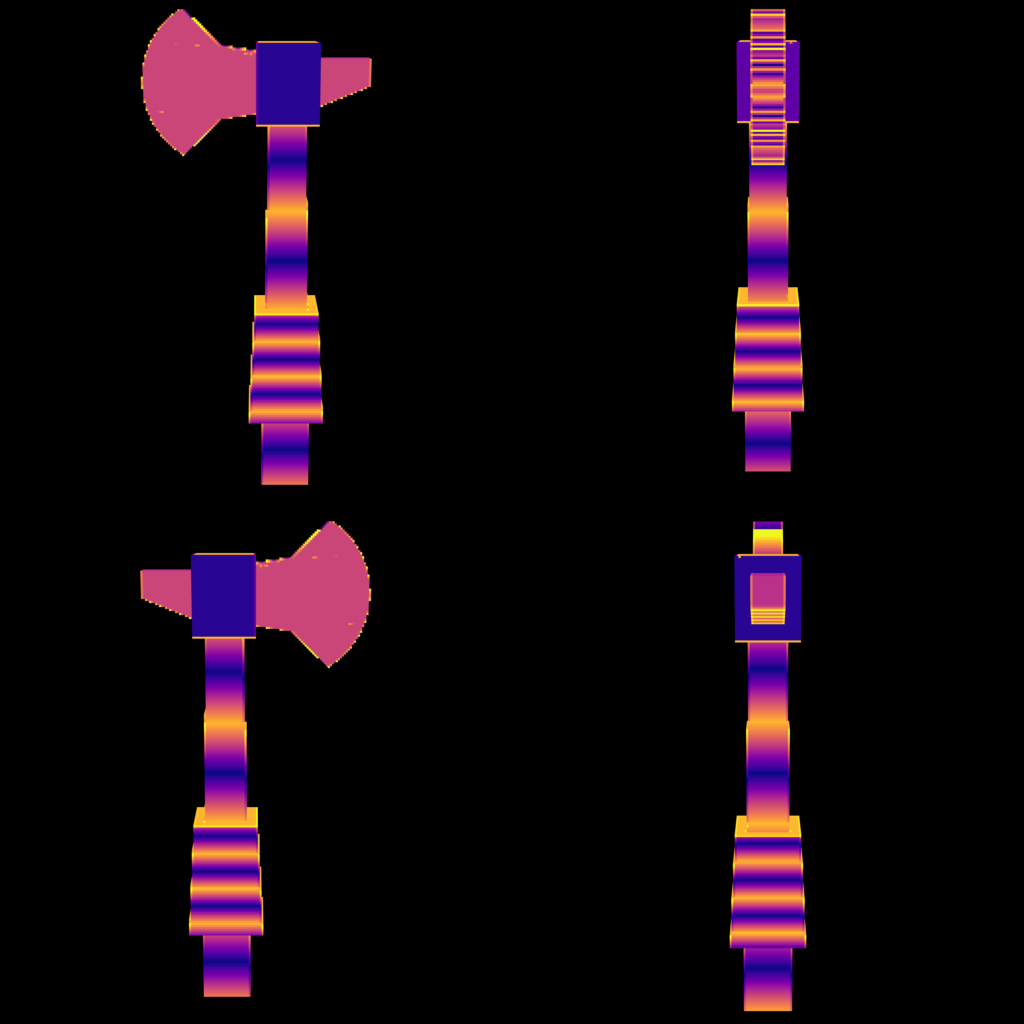

In [11]:
offset_to_projection = inputs[:, 17:20]
render_vector(offset_to_projection, title='offset_to_projection vector')
render_scalar(np.linalg.norm(offset_to_projection, axis=1), title='|offset_to_projection|', cmap='plasma')

## Offset to centroid

offset_to_centroid vector  RGB maps [-0.12817, +0.12817] to [0, 1]


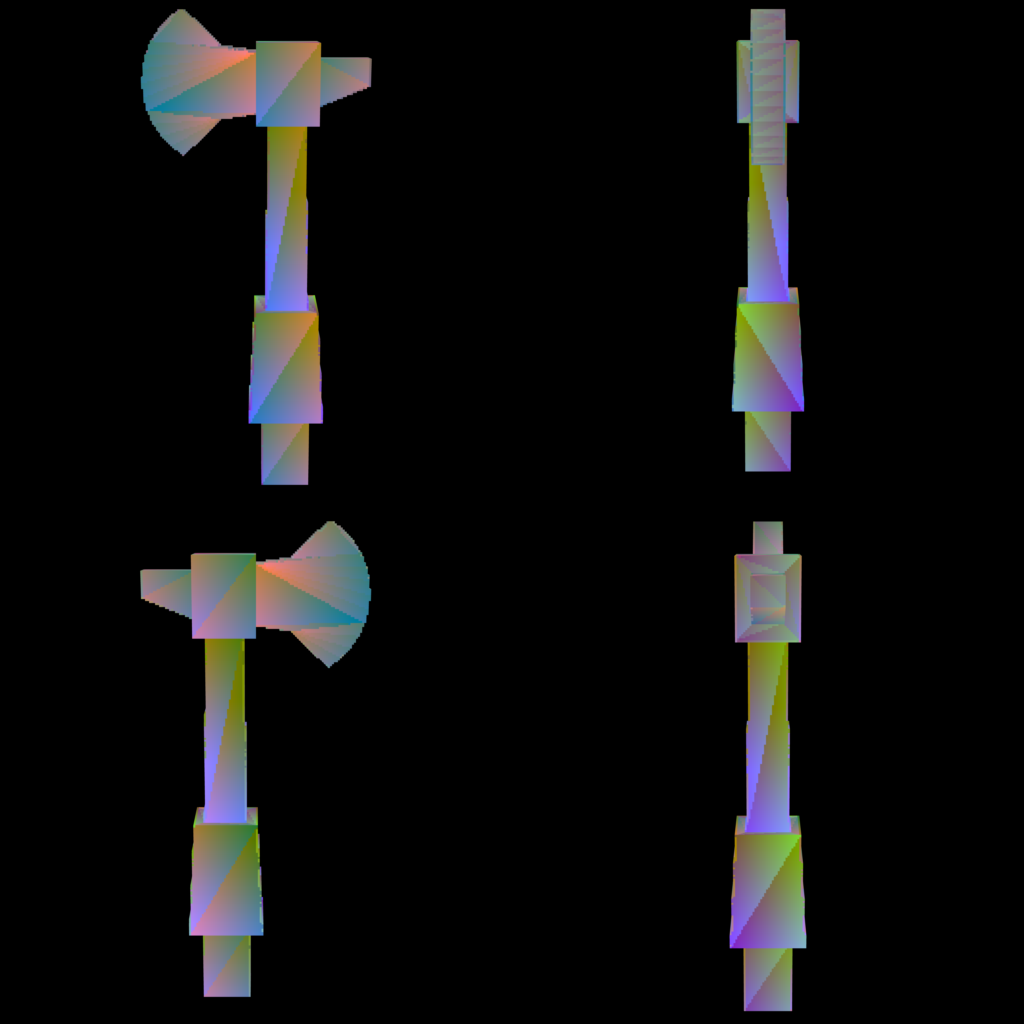

|offset_to_centroid|  range=(0.0036354323383420706, 0.17350593209266663)


/tmp/ipykernel_1873662/4122514555.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)


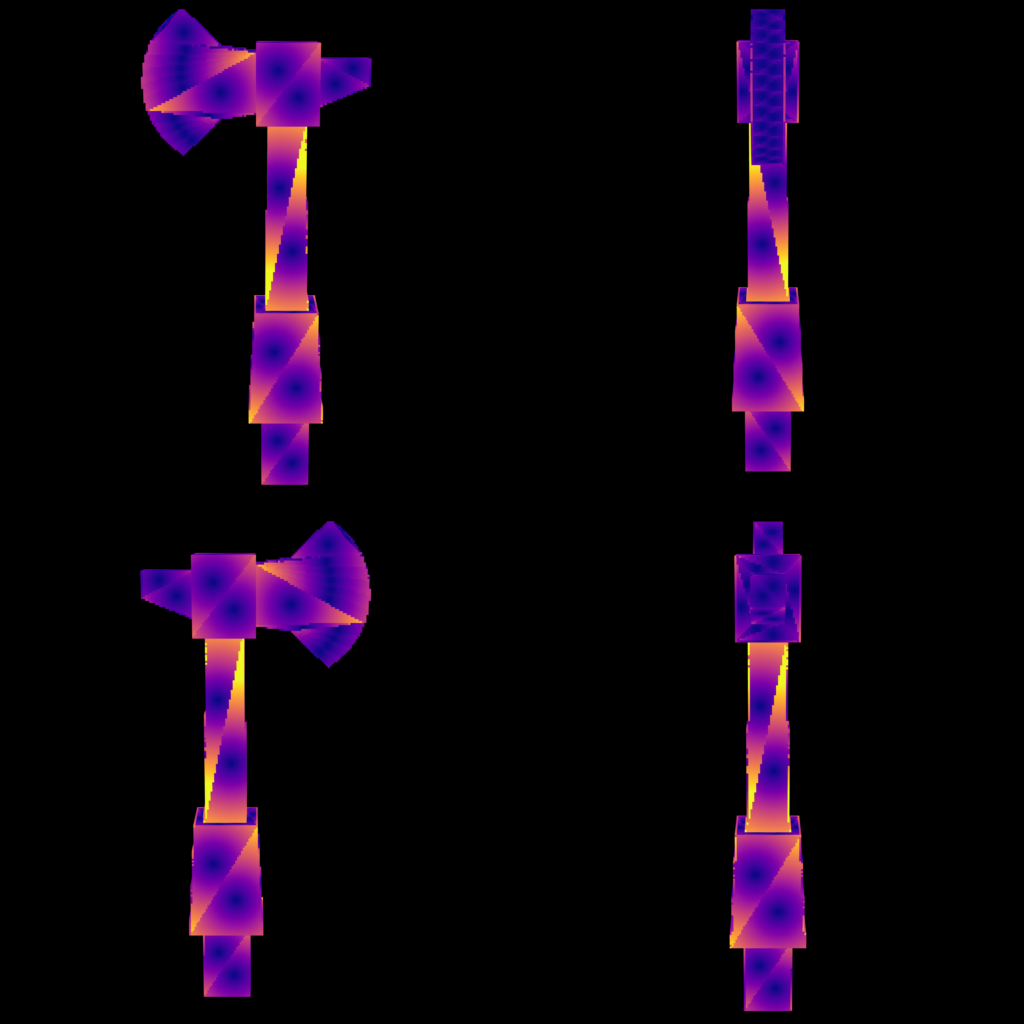

In [12]:
offset_to_centroid = inputs[:, 11:14]
render_vector(offset_to_centroid, title='offset_to_centroid vector')
render_scalar(np.linalg.norm(offset_to_centroid, axis=1), title='|offset_to_centroid|', cmap='plasma')

## Offsets to triangle vertices

offset_to_v0 vector  RGB maps [-0.35352, +0.35352] to [0, 1]


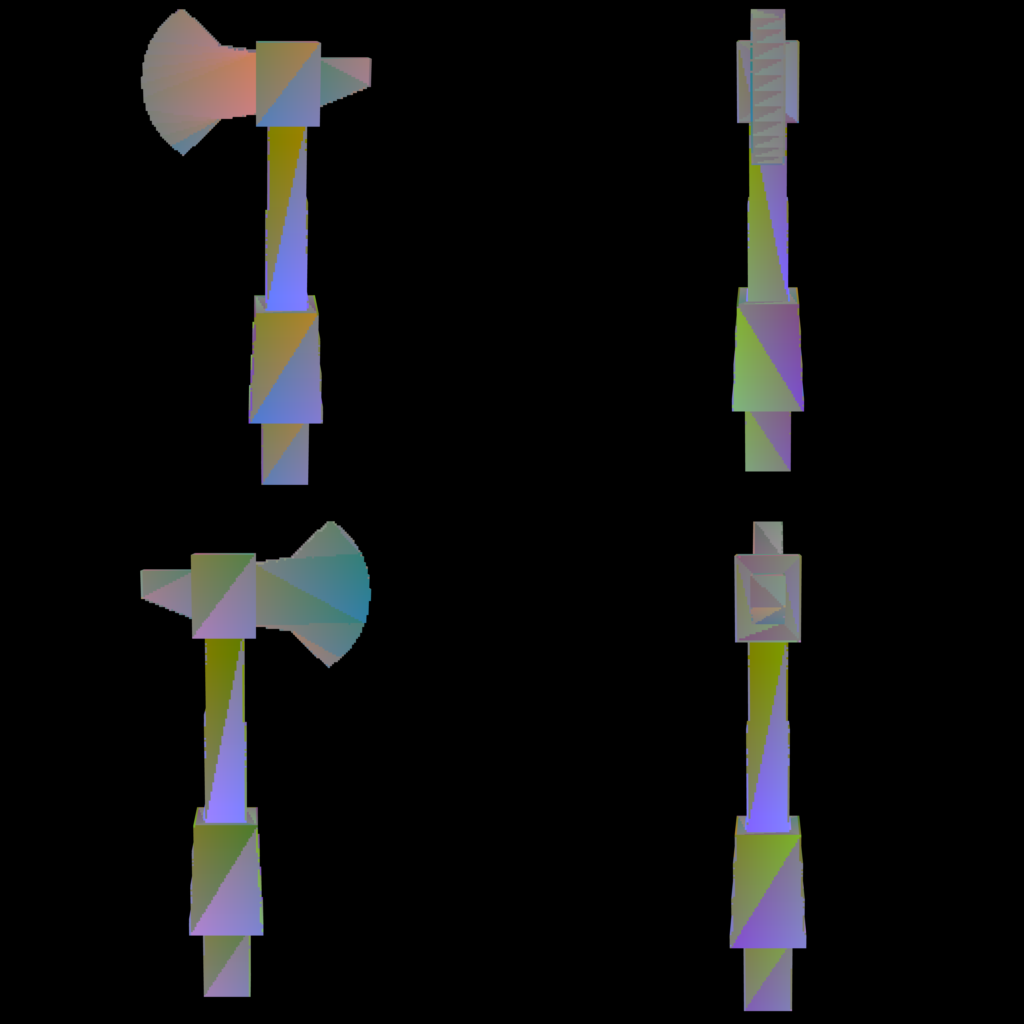

/tmp/ipykernel_1873662/4122514555.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)


|offset_to_v0|  range=(0.0094836400821805, 0.38155317306518555)


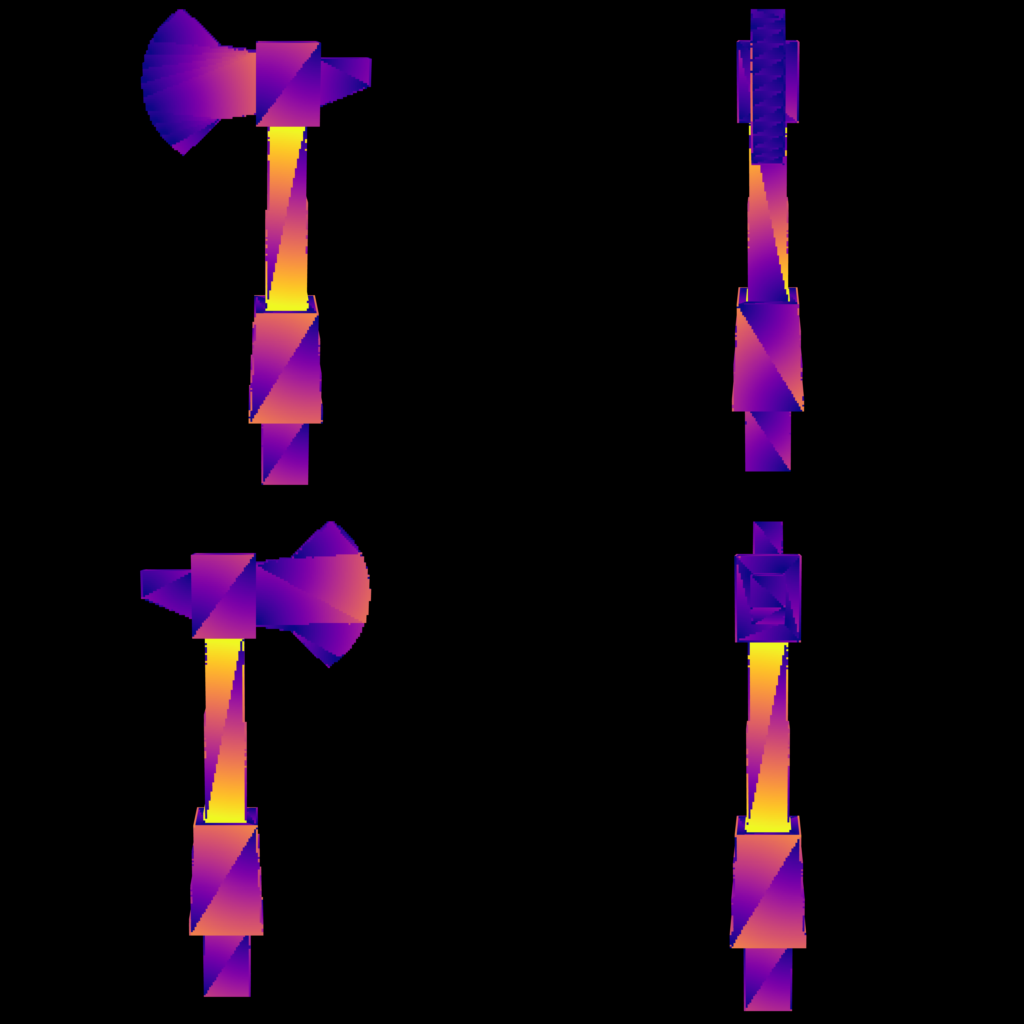

offset_to_v1 vector  RGB maps [-0.29883, +0.29883] to [0, 1]


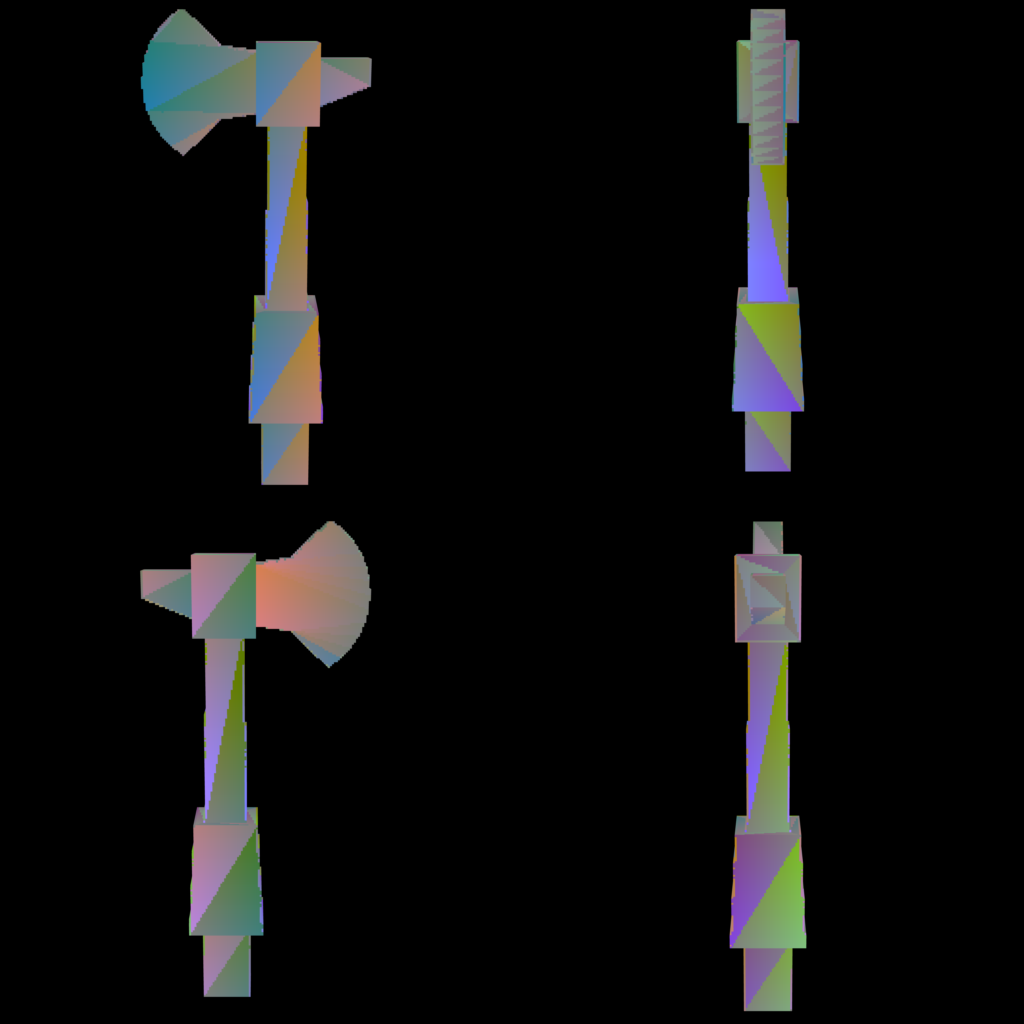

|offset_to_v1|  range=(0.009567203931510448, 0.35873937606811523)


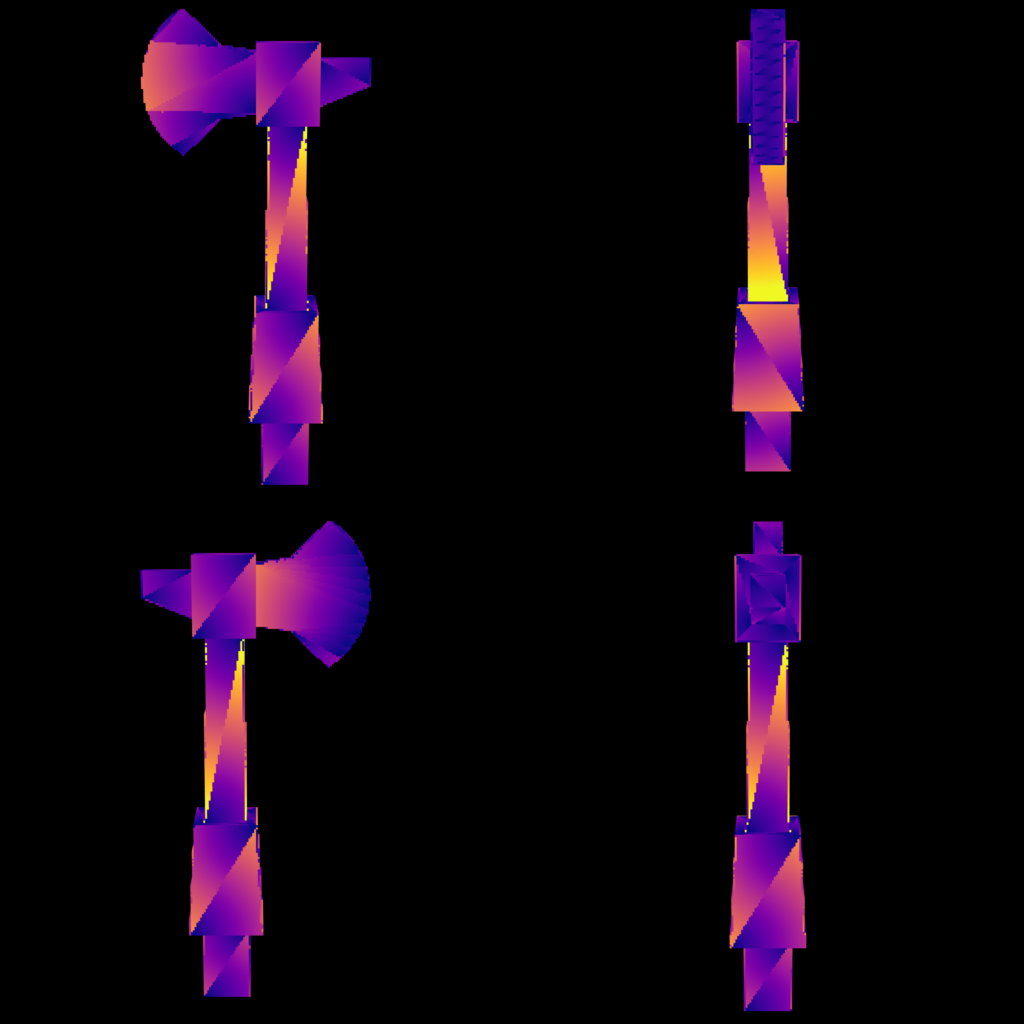

offset_to_v2 vector  RGB maps [-0.24023, +0.24023] to [0, 1]


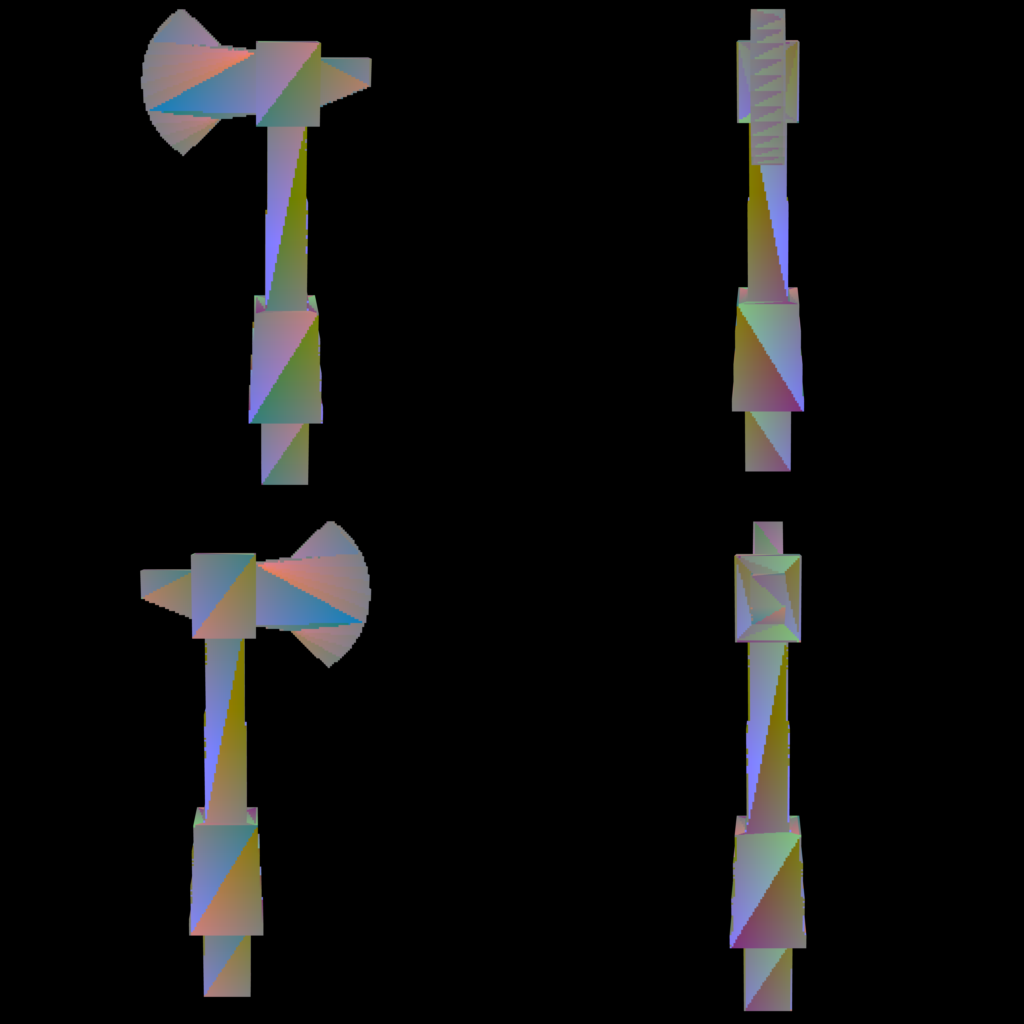

|offset_to_v2|  range=(0.007098307833075523, 0.30295443534851074)


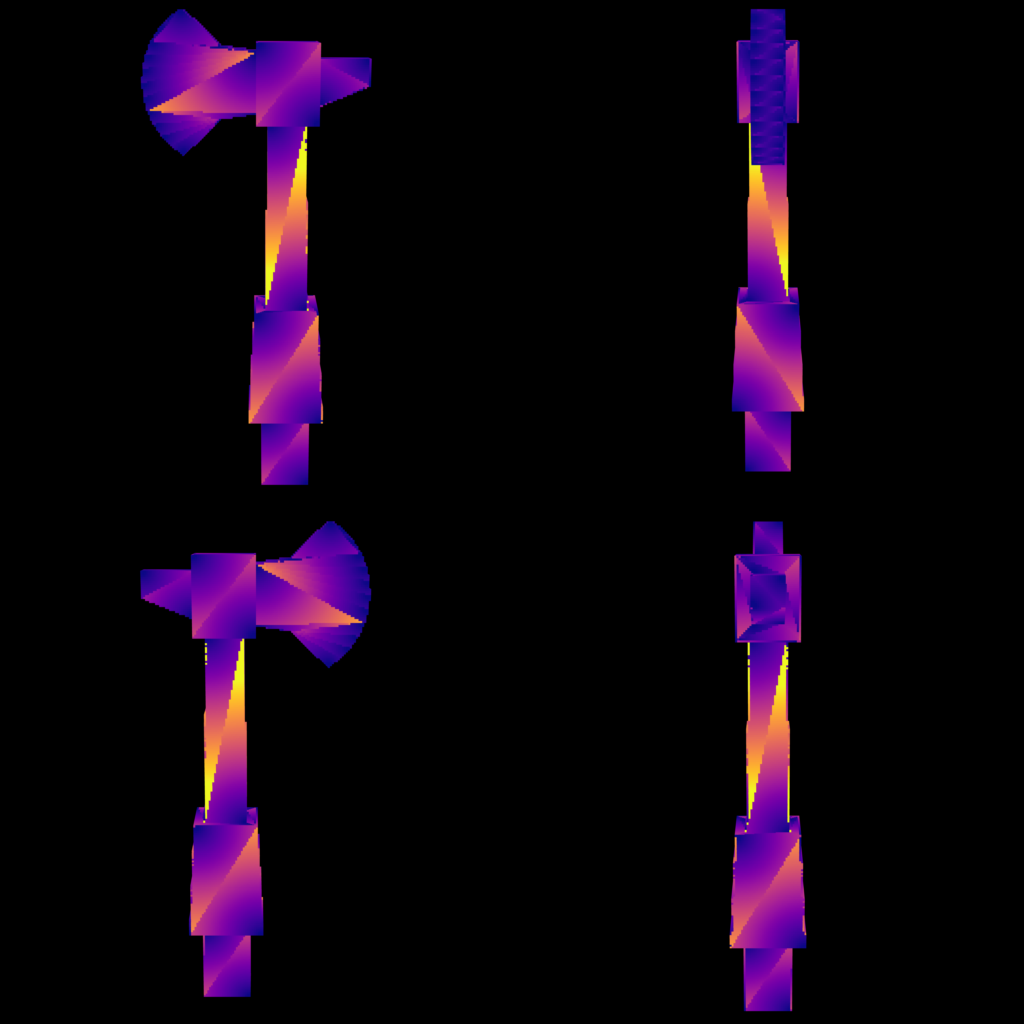

In [13]:
for label, sl in [('offset_to_v0', slice(2, 5)), ('offset_to_v1', slice(5, 8)), ('offset_to_v2', slice(8, 11))]:
    vec = inputs[:, sl]
    render_vector(vec, title=f'{label} vector')
    render_scalar(np.linalg.norm(vec, axis=1), title=f'|{label}|', cmap='plasma')

## Raw input channel browser

raw input channel 0  range=(0.0, 0.9052486419677734)


/tmp/ipykernel_1873662/4122514555.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgb = cm.get_cmap(cmap)(t)[:, :3].astype(np.float32)


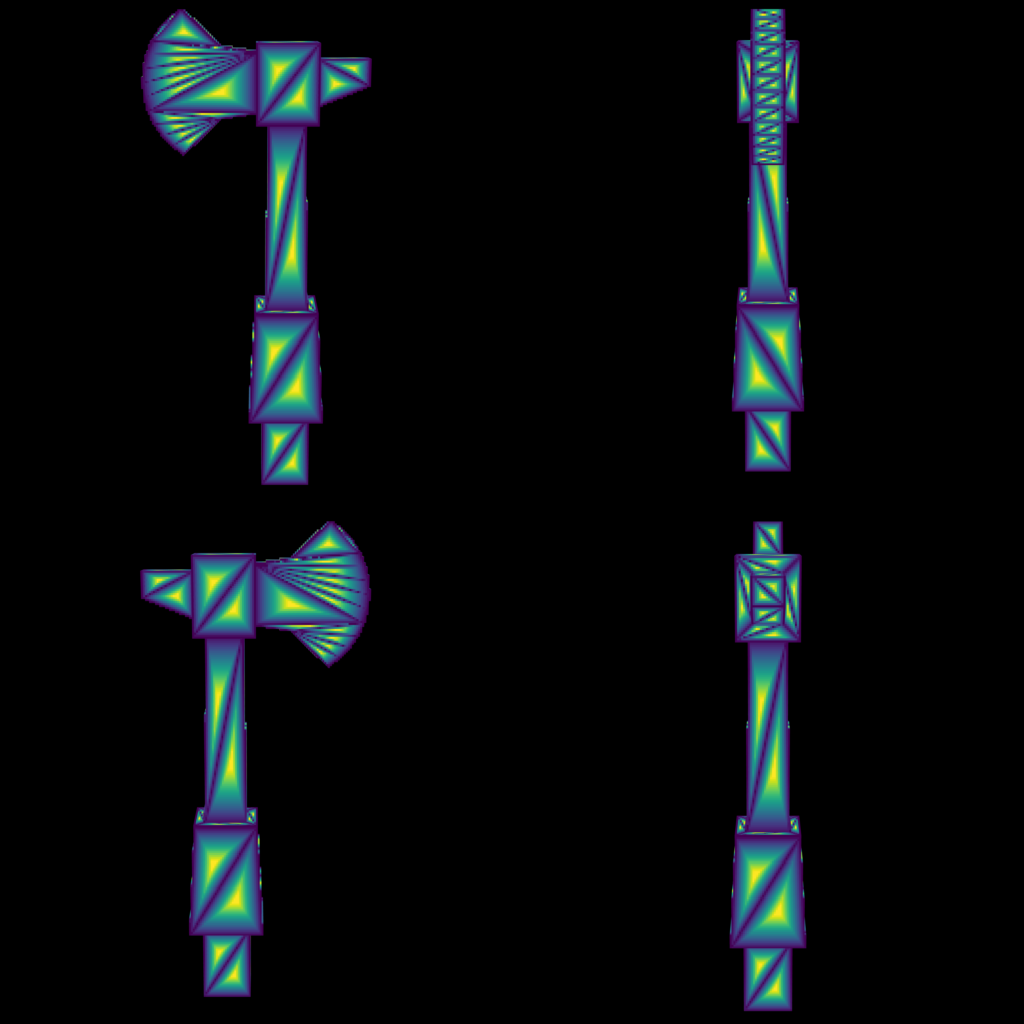

In [14]:
# Change CHANNEL_INDEX to inspect any raw stored input channel exactly.
CHANNEL_INDEX = 0
render_scalar(inputs[:, CHANNEL_INDEX], title=f'raw input channel {CHANNEL_INDEX}')

## Interactive sparse voxel point view

In [15]:
import plotly.graph_objects as go

SCALAR_FOR_PLOTLY = targets[:, 0]  # change to any scalar, e.g. targets[:, 1] or np.linalg.norm(inputs[:, 17:20], axis=1)
rng = np.random.default_rng(RANDOM_SEED)
if len(points) > POINT_SUBSAMPLE:
    idx = rng.choice(len(points), size=POINT_SUBSAMPLE, replace=False)
else:
    idx = np.arange(len(points))

fig = go.Figure(data=[go.Scatter3d(
    x=points[idx, 0], y=points[idx, 1], z=points[idx, 2],
    mode='markers',
    marker=dict(size=2, color=SCALAR_FOR_PLOTLY[idx], colorscale='Viridis', opacity=0.75, colorbar=dict(title='scalar')),
)])
fig.update_layout(scene=dict(aspectmode='data'), width=900, height=800, title=f'{sha}: sparse voxel centers')
fig.show()